# Phase 06B — OPUS-MT pretrained baseline

Notebook này là bản ghi thực nghiệm của nhánh OPUS-MT trước khi áp dụng miền CNTT. Nó dùng cùng General Test và IT Test đã sealed ở Phase 05; không fine-tune, không sửa dữ liệu test và không gộp hai test set thành một điểm chung.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'configs').is_dir():
    ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT / 'src'))

from core_mt.adapters.opus_mt import OpusMTAdapter
from core_mt.contracts import Direction
from core_mt.data import load_locked_evaluation_set
from core_mt.protocol import load_frozen_protocol

CONFIG_PATH = ROOT / 'configs' / 'opus_mt_baseline_v1.json'
PROTOCOL_PATH = ROOT / 'configs' / 'evaluation_protocol_v2.json'
RUN_ROOT = ROOT / 'runs' / 'core_mt_baseline_v2' / 'opus_mt'
config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
protocol = load_frozen_protocol(PROTOCOL_PATH)
print(f'Protocol: {protocol.protocol_version}; dataset release: {protocol.dataset_release}')

Protocol: core_mt_baseline_v2; dataset release: phase05_release_v1


## 1. Phần riêng của OPUS-MT

Shared CORE quyết định dataset, direction, seed, beam size, metric và artifact. Adapter OPUS-MT chỉ chọn checkpoint theo direction, áp dụng target-language token khi checkpoint yêu cầu, rồi gọi tokenizer/model Marian.

In [2]:
import core_mt.adapters.opus_mt as opus_module
display(Markdown(opus_module.__doc__.strip()))
display(Markdown(OpusMTAdapter.__doc__.strip()))

Adapter OPUS-MT: phần riêng duy nhất của nhánh Marian bilingual.

Shared layer đã quyết định dataset, direction, seed và generation settings.
Adapter này chỉ làm ba việc OPUS-specific: chọn checkpoint theo direction, thêm
target-language token khi model card yêu cầu, và gọi tokenizer/model Marian.
Không có rule nào phụ thuộc General Test hoặc IT Test trong file này.

Bọc hai checkpoint OPUS-MT thành cùng interface `TranslationAdapter`.

EN→VI và VI→EN là hai checkpoint khác nhau. Điều này khác model multilingual:
checkpoint được chọn trước khi inference, không phải bằng cách nhìn kết quả
test rồi chọn model tốt hơn.

In [3]:
pd.DataFrame([
    {
        'direction': direction,
        'checkpoint': spec['model_id'],
        'requested_revision': spec['revision'],
        'mandatory_prefix': spec['source_prefix'] or '(none)',
    }
    for direction, spec in config['directions'].items()
])

,direction,checkpoint,requested_revision,mandatory_prefix
0,en_to_vi,Helsinki-NLP/opus-mt-en-vi,main,>>vie<<
1,vi_to_en,Helsinki-NLP/opus-mt-vi-en,main,(none)


## 2. Kiểm tra input trước tokenizer

Đây là kiểm tra format, chưa tải checkpoint. EN→VI cần `>>vie<<`; VI→EN giữ nguyên câu nguồn. Prefix là yêu cầu giao diện của checkpoint, không phải prompt được điều chỉnh theo test set.

In [4]:
samples = {
    Direction.EN_TO_VI: 'Install the package from the repository.',
    Direction.VI_TO_EN: 'Cài đặt gói từ kho lưu trữ.',
}
pd.DataFrame([
    {
        'direction': direction.value,
        'source': text,
        'input_to_tokenizer': OpusMTAdapter(direction, CONFIG_PATH, 'cpu').prepare_input(text),
    }
    for direction, text in samples.items()
])

,direction,source,input_to_tokenizer
0,en_to_vi,Install the package from the repository.,>>vie<< Install the package from the repository.
1,vi_to_en,Cài đặt gói từ kho lưu trữ.,Cài đặt gói từ kho lưu trữ.


## 3. Protocol benchmark v2

Chất lượng và hiệu năng là hai phép đo khác nhau. Mỗi câu của General Test và IT Test được sinh bản dịch đúng một lần để tính chrF++ và SacreBLEU. Sau đó, mỗi test set chọn tối đa 128 câu bằng SHA-256 của `seed:row_id`, warm-up tối đa 32 câu, rồi đo 5 lượt trên mẫu cố định. Vì vậy benchmark giữ được tính lặp lại nhưng không dịch lặp toàn bộ corpus năm lần.

In [5]:
datasets = {name: load_locked_evaluation_set(name, ROOT) for name in protocol.evaluation_sets}
workload = pd.DataFrame([
    {
        'test_set': name,
        'quality_sentences': len(dataset.rows),
        'quality_passes': protocol.benchmark.quality_passes,
        'latency_sample_max': min(len(dataset.rows), protocol.benchmark.latency_sample_size),
        'warmup_max': min(len(dataset.rows), protocol.benchmark.warmup_sentences),
        'latency_repeats': protocol.benchmark.latency_repeats,
    }
    for name, dataset in datasets.items()
])
workload

,test_set,quality_sentences,quality_passes,latency_sample_max,warmup_max,latency_repeats
0,general_test,1012,1,128,32,5
1,it_test,13851,1,128,32,5


## 4. Lệnh chạy baseline

Cell dưới được đặt `False` để mở notebook không tự khởi chạy nhiều giờ. Khi đã sẵn sàng chạy từ notebook, đổi biến thành `True`. Runner luôn gọi lại Phase 05 gate trước khi tải model. Trong lúc chạy, thư mục `.in_progress` có log; chỉ sau khi đủ sáu artifact, runner mới đổi tên thành thư mục kết quả chính thức.

In [6]:
direction = 'en_to_vi'
final_dir = RUN_ROOT / direction
active_dir = RUN_ROOT / f'{direction}.in_progress'
RUN_FULL_BASELINE = True
if active_dir.is_dir():
    print('Đã có run dở dang. Đọc cell trạng thái/log; không khởi chạy chồng lên run này.')
elif final_dir.is_dir():
    print('Baseline EN→VI đã hoàn thành. Đọc cell kết quả phía dưới.')
elif RUN_FULL_BASELINE:
    command = [
        sys.executable, 'tools/run_opus_mt_baseline.py',
        '--direction', 'en_to_vi', '--device', 'cpu',
        '--progress-interval', '250', '--preview', '2',
    ]
    # Kernel Windows mặc định đọc pipe bằng CP1252; model có thể in UTF-8.
    # Tự giải mã UTF-8 để log tiếng Việt không làm reader thread lỗi.
    result = subprocess.run(
        command, cwd=ROOT, text=True, capture_output=True,
        encoding='utf-8', errors='replace',
    )
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    print(f'Exit code: {result.returncode}')
else:
    print('Đặt RUN_FULL_BASELINE = True chỉ khi chưa có run dở dang hoặc completed run.')

Baseline EN→VI đã hoàn thành. Đọc cell kết quả phía dưới.


## 5. Theo dõi trạng thái và log

Cell này chỉ đọc file. Nó hoạt động cả trước khi chạy, khi đang chạy và sau khi hoàn thành.

In [7]:
direction = 'en_to_vi'
final_dir = RUN_ROOT / direction
active_dir = RUN_ROOT / f'{direction}.in_progress'
run_dir = final_dir if final_dir.is_dir() else active_dir

if not run_dir.is_dir():
    print('Chưa có run OPUS-MT EN→VI v2.')
else:
    state = 'COMPLETED' if run_dir == final_dir else 'IN PROGRESS — chưa phải kết quả cuối'
    print(f'State: {state}')
    print('Artifacts:', sorted(path.name for path in run_dir.iterdir()))
    log = run_dir / 'run.log'
    if log.is_file():
        print('\n'.join(log.read_text(encoding='utf-8').splitlines()[-20:]))

State: COMPLETED
Artifacts: ['benchmark.json', 'environment.txt', 'metrics.json', 'predictions.jsonl', 'resolved_config.json', 'run.log']
[it_test] quality: 12500/13851 sentences
[it_test] quality: 12750/13851 sentences
[it_test] quality: 13000/13851 sentences
[it_test] quality: 13250/13851 sentences
[it_test] quality: 13500/13851 sentences
[it_test] quality: 13750/13851 sentences
[it_test] quality: 13851/13851 sentences
[it_test] latency probe: 128 deterministic sentences × 5 repeats
[it_test] repeat 1/5 started
[it_test] repeat 1: 128/128 probe sentences
[it_test] repeat 2/5 started
[it_test] repeat 2: 128/128 probe sentences
[it_test] repeat 3/5 started
[it_test] repeat 3: 128/128 probe sentences
[it_test] repeat 4/5 started
[it_test] repeat 4: 128/128 probe sentences
[it_test] repeat 5/5 started
[it_test] repeat 5: 128/128 probe sentences
[it_test] chrF++=50.7150; SacreBLEU=31.6095
Baseline completed successfully.


## 6. Đọc prediction, metric và benchmark sau khi hoàn thành

Không có số liệu giả trong notebook. Nếu run chưa hoàn thành, cell sẽ báo trạng thái thay vì tự tạo chrF++, SacreBLEU, RAM hoặc latency.

In [8]:
if not final_dir.is_dir():
    print('Metrics chưa có: chờ run EN→VI hoàn thành và được commit thành thư mục kết quả.')
else:
    metrics = json.loads((final_dir / 'metrics.json').read_text(encoding='utf-8'))['by_test_set']
    benchmark = json.loads((final_dir / 'benchmark.json').read_text(encoding='utf-8'))['by_test_set']
    predictions = [json.loads(line) for line in (final_dir / 'predictions.jsonl').read_text(encoding='utf-8').splitlines()]
    display(pd.DataFrame(predictions)[['test_set', 'row_id', 'source', 'reference', 'prediction']].head(8))
    display(pd.DataFrame(metrics).T.rename_axis('test_set'))
    display(pd.DataFrame(benchmark).T.rename_axis('test_set'))

,test_set,row_id,source,reference,prediction
0,general_test,0,"""We now have 4-month-old mice that are non-dia...",“Chúng tôi hiện có đàn chuột 4 tháng tuổi đã h...,"""Bây giờ chúng tôi có những con chuột 4 tháng ..."
1,general_test,1,"Dr. Ehud Ur, professor of medicine at Dalhousi...","Tiến sĩ Ehud Ur, giáo sư y khoa của Trường Đại...","Tiến sĩ Isaiah Ur, giáo sư y khoa tại Đại học ..."
2,general_test,2,"Like some other experts, he is skeptical about...","Giống như một số chuyên gia khác, ông ấy hoài ...","Giống như một số chuyên gia khác, ông hoài ngh..."
3,general_test,3,"On Monday, Sara Danius, permanent secretary of...","Vào ngày thứ Hai, Sara Danius, thư ký thường t...","Vào thứ hai, Sara Danius, thư ký lâu dài của Ủ..."
4,general_test,4,"Danius said, ""Right now we are doing nothing. ...","Danius đã nói, “Ngay lúc này chúng ta chẳng là...","Danius nói, ""Ngay bây giờ chúng ta không làm g..."
5,general_test,5,"Previously, Ring's CEO, Jamie Siminoff, remark...","Trước đây, giám đốc điều hành của Ring, Jamie ...","Trước đó, CEO của Ring's, Jamie Siminoff, nhận..."
6,general_test,6,"He built a WiFi door bell, he said.","Ông đã lắp môt chuông cửa WiFi, ông cho biết.",Ông ấy làm chuông cửa WiFi.
7,general_test,7,Siminoff said sales boosted after his 2013 app...,Siminoff cho biết doanh số tăng sau sự xuất hi...,Sibinoff nói doanh số tăng sau khi xuất hiện n...


,chrF++,sacreBLEU,sacrebleu_version
test_set,,,
general_test,52.115653,30.050171,2.6.0
it_test,50.714956,31.609514,2.6.0


,quality_sentences,quality_passes,latency_sample_size,latency_sample_seed,warmup_sentences,latency_repeats,latency_unit,peak_process_rss_bytes,latency_median_ms,latency_p95_ms
test_set,,,,,,,,,,
general_test,1012,1,128,42,32,5,milliseconds per sentence,871157760,660.6714,1101.2045
it_test,13851,1,128,42,32,5,milliseconds per sentence,930766848,365.7972,610.0683


## 7. Biểu đồ General Test và IT Test

Hai cột được giữ riêng. Chỉ khi cả hai có metric hoàn chỉnh thì biểu đồ mới xuất hiện; không tính trung bình giữa hai miền.

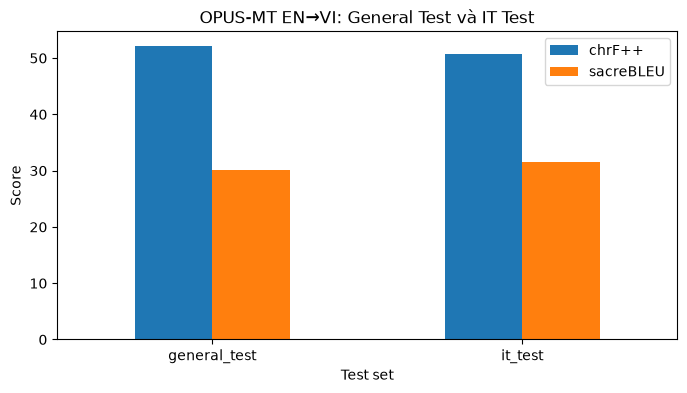

In [9]:
if final_dir.is_dir():
    metric_table = pd.DataFrame(metrics).T[['chrF++', 'sacreBLEU']]
    ax = metric_table.plot.bar(rot=0, figsize=(8, 4), title='OPUS-MT EN→VI: General Test và IT Test')
    ax.set_xlabel('Test set')
    ax.set_ylabel('Score')
else:
    print('Biểu đồ sẽ xuất hiện sau khi metrics.json được tạo.')

## 8. Unit test không tải checkpoint

Các test kiểm tra adapter, protocol v2 và contract artifact. Chúng không thay thế inference thật; kết quả baseline chỉ hợp lệ khi runner hoàn thành toàn bộ artifact.

In [10]:
for pattern in ['test_core_shared.py', 'test_opus_mt_adapter.py', 'test_runner_contract.py']:
    result = subprocess.run(
        [sys.executable, '-m', 'unittest', 'discover', '-s', 'tests', '-p', pattern],
        cwd=ROOT, text=True, capture_output=True,
    )
    print(result.stdout + result.stderr)
    assert result.returncode == 0, pattern

...
----------------------------------------------------------------------
Ran 3 tests in 0.012s

OK

...
----------------------------------------------------------------------
Ran 3 tests in 0.001s

OK



..
----------------------------------------------------------------------
Ran 2 tests in 0.059s

OK

